In [84]:
import zipfile
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
import numpy as np

In [85]:
# Load a sample dataset (MNIST for simplicity)
(x_train, y_train), (x_test, y_test) = keras.datasets.mnist.load_data()

In [86]:
# Normalize and reshape data
x_train = x_train.astype("float32") / 255.0
x_test = x_test.astype("float32") / 255.0
x_train = np.expand_dims(x_train, axis=-1) # Add channel dimension
x_test = np.expand_dims(x_test, axis=-1)


In [87]:
# Define a simple CNN model
model = keras.Sequential([
layers.Conv2D(32, (3, 3), activation="relu", input_shape=(28, 28, 1)),
layers.MaxPooling2D((2, 2)),
layers.Conv2D(64, (3, 3), activation="relu"),
layers.MaxPooling2D((2, 2)),
layers.Flatten(),
layers.Dense(128, activation="relu"),
layers.Dense(10, activation="softmax") # 10 classes for MNIST digits
])


/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [88]:
# Compile the model
model.compile(optimizer="adam",
loss="sparse_categorical_crossentropy",
metrics=["accuracy"])


In [89]:
# Train the model
model.fit(x_train, y_train, epochs=5, batch_size=32, validation_data=(x_test, y_test))

Epoch 1/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 14s 5ms/step - accuracy: 0.9590 - loss: 0.1338 - val_accuracy: 0.9866 - val_loss: 0.0443
Epoch 2/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - accuracy: 0.9865 - loss: 0.0441 - val_accuracy: 0.9882 - val_loss: 0.0354
Epoch 3/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - accuracy: 0.9905 - loss: 0.0297 - val_accuracy: 0.9916 - val_loss: 0.0261
Epoch 4/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - accuracy: 0.9937 - loss: 0.0206 - val_accuracy: 0.9906 - val_loss: 0.0278
Epoch 5/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 8s 4ms/step - accuracy: 0.9952 - loss: 0.0152 - val_accuracy: 0.9919 - val_loss: 0.0284


In [90]:
model.summary()

Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_6 (Conv2D)               │ (None, 26, 26, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_6 (MaxPooling2D)  │ (None, 13, 13, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_7 (Conv2D)               │ (None, 11, 11, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_7 (MaxPooling2D)  │ (None, 5, 5, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_3 (Flatten)             │ (None, 1600)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 128)            │       204,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 675,104 (2.58 MB)

 Trainable params: 225,034 (879.04 KB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 450,070 (1.72 MB)

In [91]:
model.compile(optimizer="adam",
loss="sparse_categorical_crossentropy",
metrics=["accuracy"])


In [92]:
# Train the model
model.fit(x_train, y_train, epochs=5, batch_size=32, validation_data=(x_test, y_test))

Epoch 1/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 11s 5ms/step - accuracy: 0.9957 - loss: 0.0130 - val_accuracy: 0.9921 - val_loss: 0.0274
Epoch 2/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - accuracy: 0.9970 - loss: 0.0092 - val_accuracy: 0.9902 - val_loss: 0.0398
Epoch 3/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - accuracy: 0.9973 - loss: 0.0082 - val_accuracy: 0.9905 - val_loss: 0.0385
Epoch 4/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 10s 4ms/step - accuracy: 0.9973 - loss: 0.0069 - val_accuracy: 0.9921 - val_loss: 0.0311
Epoch 5/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - accuracy: 0.9983 - loss: 0.0054 - val_accuracy: 0.9921 - val_loss: 0.0282


In [93]:
# Evaluate the model
test_loss, test_acc = model.evaluate(x_test, y_test)
print(f"Test accuracy: {test_acc:.4f}")


313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9921 - loss: 0.0282
Test accuracy: 0.9921


In [94]:
# Make predictions
predictions = model.predict(x_test[:5])
predicted_labels = np.argmax(predictions, axis=1)
print("Predicted labels:", predicted_labels)
print("Actual labels: ", y_test[:5])

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 356ms/step
Predicted labels: [7 2 1 0 4]
Actual labels:  [7 2 1 0 4]


In [95]:

history = model.fit(x_train, y_train, epochs=1, batch_size=32, validation_data=(x_test, y_test))
print(history.history)

1875/1875 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - accuracy: 0.9984 - loss: 0.0053 - val_accuracy: 0.9916 - val_loss: 0.0365
{'accuracy': [0.9983500242233276], 'loss': [0.005313125904649496], 'val_accuracy': [0.991599977016449], 'val_loss': [0.03648170456290245]}


### Exersice

In [96]:
!pip install -q pillow

In [97]:
from google.colab import files
uploaded = files.upload()


Saving FruitinAmazon.zip to FruitinAmazon (1).zip


In [98]:
# Import libraries
# Import libraries
import os
import zipfile
import random
import shutil
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image
import tensorflow as tf
from tensorflow.keras import layers, models
from tensorflow.keras.callbacks import ModelCheckpoint, EarlyStopping
from tensorflow.keras.models import load_model
from sklearn.metrics import classification_report, confusion_matrix

In [99]:
zip_path = "/content/FruitinAmazon.zip"
extract_path = "/content/FruitinAmazon"


In [100]:
import zipfile

with zipfile.ZipFile(zip_path, "r") as zip_ref:
    zip_ref.extractall(extract_path)

print("Dataset extracted successfully")

Dataset extracted successfully


In [101]:
# Show folder structure
for root, dirs, files_in_dir in os.walk(extract_path):
    print(root)

# Find train and test folders automatically
train_dir = None
test_dir = None

for root, dirs, files_in_dir in os.walk(extract_path):
    dir_names = [d.lower() for d in dirs]
    if "train" in dir_names and "test" in dir_names:
        train_dir = os.path.join(root, "train")
        test_dir = os.path.join(root, "test")
        break

print("Train directory:", train_dir)
print("Test directory:", test_dir)

# Stop if folders are not found
if train_dir is None or test_dir is None:
    raise FileNotFoundError("train and test folders not found inside extracted dataset")


/content/FruitinAmazon
/content/FruitinAmazon/FruitinAmazon
/content/FruitinAmazon/FruitinAmazon/test
/content/FruitinAmazon/FruitinAmazon/test/graviola
/content/FruitinAmazon/FruitinAmazon/test/guarana
/content/FruitinAmazon/FruitinAmazon/test/acai
/content/FruitinAmazon/FruitinAmazon/test/cupuacu
/content/FruitinAmazon/FruitinAmazon/test/tucuma
/content/FruitinAmazon/FruitinAmazon/test/pupunha
/content/FruitinAmazon/FruitinAmazon/train
/content/FruitinAmazon/FruitinAmazon/train/graviola
/content/FruitinAmazon/FruitinAmazon/train/guarana
/content/FruitinAmazon/FruitinAmazon/train/acai
/content/FruitinAmazon/FruitinAmazon/train/cupuacu
/content/FruitinAmazon/FruitinAmazon/train/tucuma
/content/FruitinAmazon/FruitinAmazon/train/pupunha
Train directory: /content/FruitinAmazon/FruitinAmazon/train
Test directory: /content/FruitinAmazon/FruitinAmazon/test


In [102]:
with zipfile.ZipFile(zip_path, "r") as zip_ref:
    zip_ref.extractall(extract_path)

print("Dataset extracted successfully")


Dataset extracted successfully


In [108]:
# Set paths
train_dir = "/content/FruitinAmazon/FruitinAmazon/train"
test_dir = "/content/FruitinAmazon/FruitinAmazon/train"

In [109]:
# Set parameters
img_height = 128
img_width = 128
batch_size = 16
validation_split = 0.2
seed = 123

In [110]:
# Get class names
class_names = sorted([d for d in os.listdir(train_dir) if os.path.isdir(os.path.join(train_dir, d))])
print("Classes:", class_names)

# Display one random image from each class
sample_images = []

Classes: ['acai', 'cupuacu', 'graviola', 'guarana', 'pupunha', 'tucuma']


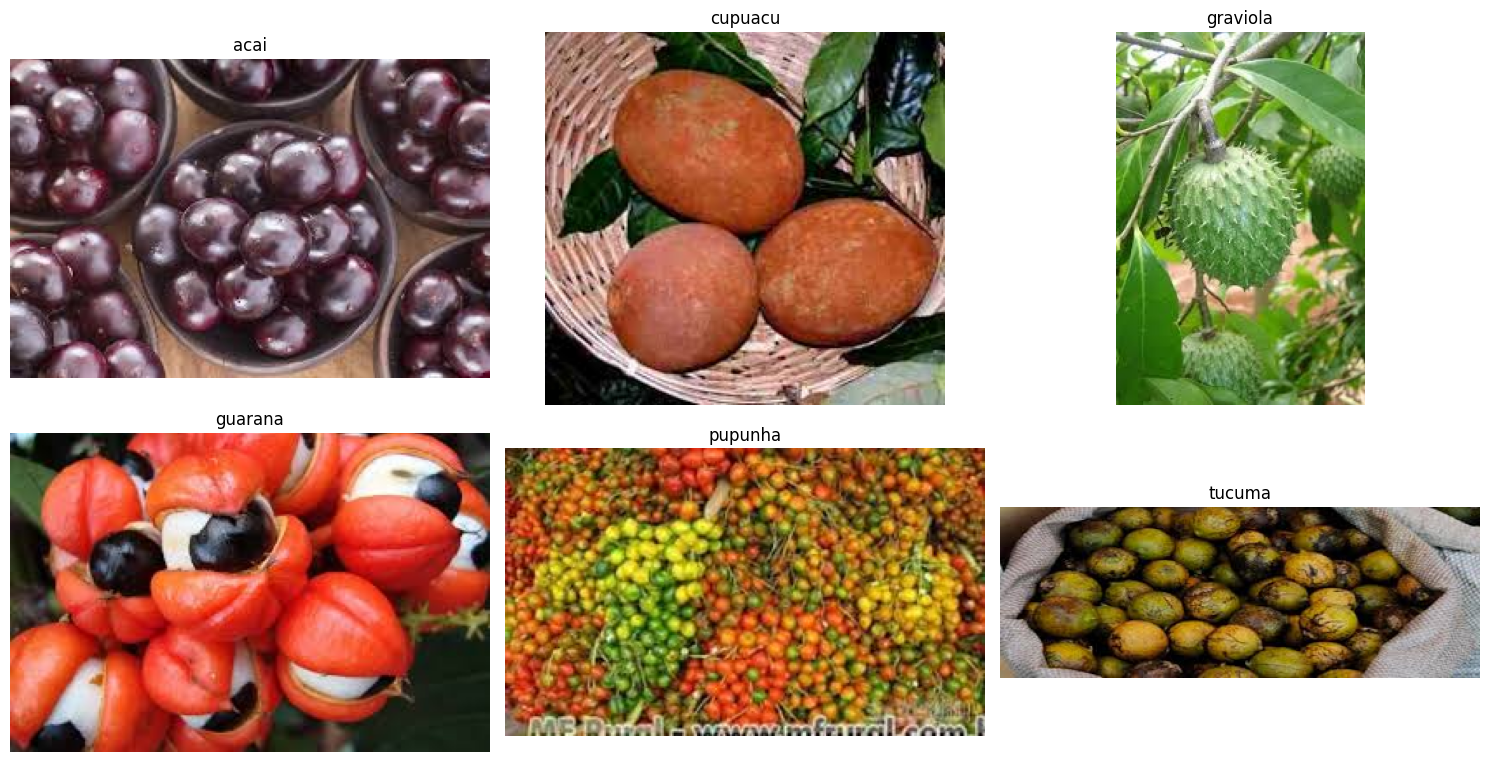

In [111]:
for class_name in class_names:
    class_path = os.path.join(train_dir, class_name)
    image_files = [f for f in os.listdir(class_path) if os.path.isfile(os.path.join(class_path, f))]
    if len(image_files) > 0:
        random_image = random.choice(image_files)
        sample_images.append((class_name, os.path.join(class_path, random_image)))

cols = 3
rows = int(np.ceil(len(sample_images) / cols))
plt.figure(figsize=(15, 8))

for i, (class_name, image_path) in enumerate(sample_images):
    img = Image.open(image_path)
    plt.subplot(rows, cols, i + 1)
    plt.imshow(img)
    plt.title(class_name)
    plt.axis("off")

plt.tight_layout()
plt.show()

In [112]:
# Check and remove corrupted images from train folder
corrupted_images = []

for class_name in class_names:
    class_path = os.path.join(train_dir, class_name)
    for file_name in os.listdir(class_path):
        image_path = os.path.join(class_path, file_name)
        if os.path.isfile(image_path):
            try:
                with Image.open(image_path) as img:
                    img.verify()
            except (IOError, SyntaxError, OSError):
                corrupted_images.append(image_path)
                os.remove(image_path)
                print(f"Removed corrupted image: {image_path}")

# Check and remove corrupted images from test folder
test_class_names = sorted([d for d in os.listdir(test_dir) if os.path.isdir(os.path.join(test_dir, d))])

for class_name in test_class_names:
    class_path = os.path.join(test_dir, class_name)
    for file_name in os.listdir(class_path):
        image_path = os.path.join(class_path, file_name)
        if os.path.isfile(image_path):
            try:
                with Image.open(image_path) as img:
                    img.verify()
            except (IOError, SyntaxError, OSError):
                corrupted_images.append(image_path)
                os.remove(image_path)
                print(f"Removed corrupted image: {image_path}")

if len(corrupted_images) == 0:
    print("No Corrupted Images Found.")


No Corrupted Images Found.


In [113]:
# Create training dataset
train_ds = tf.keras.preprocessing.image_dataset_from_directory(
    train_dir,
    labels="inferred",
    label_mode="int",
    image_size=(img_height, img_width),
    interpolation="nearest",
    batch_size=batch_size,
    shuffle=True,
    validation_split=validation_split,
    subset="training",
    seed=seed
)



Found 90 files belonging to 6 classes.
Using 72 files for training.


In [114]:
# Create validation dataset
val_ds = tf.keras.preprocessing.image_dataset_from_directory(
    train_dir,
    labels="inferred",
    label_mode="int",
    image_size=(img_height, img_width),
    interpolation="nearest",
    batch_size=batch_size,
    shuffle=False,
    validation_split=validation_split,
    subset="validation",
    seed=seed
)

Found 90 files belonging to 6 classes.
Using 18 files for validation.


In [115]:
# Create test dataset
test_ds = tf.keras.preprocessing.image_dataset_from_directory(
    test_dir,
    labels="inferred",
    label_mode="int",
    image_size=(img_height, img_width),
    interpolation="nearest",
    batch_size=batch_size,
    shuffle=False
)

Found 90 files belonging to 6 classes.


In [116]:
# Save class names from dataset
class_names = train_ds.class_names
num_classes = len(class_names)
print("Detected classes:", class_names)


Detected classes: ['acai', 'cupuacu', 'graviola', 'guarana', 'pupunha', 'tucuma']


In [117]:
# Normalize datasets
rescale = tf.keras.layers.Rescaling(1./255)
train_ds = train_ds.map(lambda x, y: (rescale(x), y))
val_ds = val_ds.map(lambda x, y: (rescale(x), y))
test_ds = test_ds.map(lambda x, y: (rescale(x), y))

In [118]:
# Improve input pipeline speed
AUTOTUNE = tf.data.AUTOTUNE
train_ds = train_ds.prefetch(buffer_size=AUTOTUNE)
val_ds = val_ds.prefetch(buffer_size=AUTOTUNE)
test_ds = test_ds.prefetch(buffer_size=AUTOTUNE)

In [119]:
# Build CNN model
model = models.Sequential([
    layers.Input(shape=(img_height, img_width, 3)),
    layers.Conv2D(32, (3, 3), padding="same", strides=1, activation="relu"),
    layers.MaxPooling2D((2, 2), strides=2),
    layers.Conv2D(32, (3, 3), padding="same", strides=1, activation="relu"),
    layers.MaxPooling2D((2, 2), strides=2),
    layers.Flatten(),
    layers.Dense(64, activation="relu"),
    layers.Dense(128, activation="relu"),
    layers.Dense(num_classes, activation="softmax")
])

In [120]:
# Show model summary
model.summary()


Model: "sequential_4"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_8 (Conv2D)               │ (None, 128, 128, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_8 (MaxPooling2D)  │ (None, 64, 64, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_9 (Conv2D)               │ (None, 64, 64, 32)     │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_9 (MaxPooling2D)  │ (None, 32, 32, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_4 (Flatten)             │ (None, 32768)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ (None, 64)             │     2,097,216 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_9 (Dense)                 │ (None, 128)            │         8,320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_10 (Dense)                │ (None, 6)              │           774 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,116,454 (8.07 MB)

 Trainable params: 2,116,454 (8.07 MB)

 Non-trainable params: 0 (0.00 B)

In [121]:
# Compile model
model.compile(
    optimizer="adam",
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)


In [122]:
# Create callbacks
checkpoint = ModelCheckpoint(
    "best_cnn_model.h5",
    monitor="val_accuracy",
    save_best_only=True,
    mode="max",
    verbose=1
)
early_stopping = EarlyStopping(
    monitor="val_loss",
    patience=15,
    restore_best_weights=True,
    verbose=1
)

In [123]:
# Train model
history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=250,
    callbacks=[checkpoint, early_stopping]
)

Epoch 1/250
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 506ms/step - accuracy: 0.1260 - loss: 2.2024
Epoch 1: val_accuracy improved from None to 0.00000, saving model to best_cnn_model.h5



Epoch 1: finished saving model to best_cnn_model.h5
5/5 ━━━━━━━━━━━━━━━━━━━━ 8s 969ms/step - accuracy: 0.1250 - loss: 2.2021 - val_accuracy: 0.0000e+00 - val_loss: 1.9942
Epoch 2/250
1/5 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step - accuracy: 0.1250 - loss: 1.9459
Epoch 2: val_accuracy did not improve from 0.00000
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step - accuracy: 0.1944 - loss: 1.7862 - val_accuracy: 0.0000e+00 - val_loss: 1.8978
Epoch 3/250
1/5 ━━━━━━━━━━━━━━━━━━━━ 0s 50ms/step - accuracy: 0.1875 - loss: 1.7510
Epoch 3: val_accuracy did not improve from 0.00000
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step - accuracy: 0.2083 - loss: 1.6901 - val_accuracy: 0.0000e+00 - val_loss: 1.9483
Epoch 4/250
4/5 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step - accuracy: 0.1914 - loss: 1.6299
Epoch 4: val_accuracy improved from 0.00000 to 0.55556, saving model to best_cnn_model.h5



Epoch 4: finished saving model to best_cnn_model.h5
5/5 ━━━━━━━━━━━━━━━━━━━━ 1s 120ms/step - accuracy: 0.2083 - loss: 1.5964 - val_accuracy: 0.5556 - val_loss: 1.6806
Epoch 5/250
4/5 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - accuracy: 0.4245 - loss: 1.3892 
Epoch 5: val_accuracy improved from 0.55556 to 0.72222, saving model to best_cnn_model.h5



Epoch 5: finished saving model to best_cnn_model.h5
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 68ms/step - accuracy: 0.5000 - loss: 1.3493 - val_accuracy: 0.7222 - val_loss: 1.3956
Epoch 6/250
4/5 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step - accuracy: 0.7135 - loss: 1.1576
Epoch 6: val_accuracy did not improve from 0.72222
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step - accuracy: 0.7361 - loss: 1.0365 - val_accuracy: 0.5000 - val_loss: 1.3930
Epoch 7/250
1/5 ━━━━━━━━━━━━━━━━━━━━ 0s 69ms/step - accuracy: 0.9375 - loss: 0.6548
Epoch 7: val_accuracy improved from 0.72222 to 0.77778, saving model to best_cnn_model.h5



Epoch 7: finished saving model to best_cnn_model.h5
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 60ms/step - accuracy: 0.7639 - loss: 0.7645 - val_accuracy: 0.7778 - val_loss: 0.8609
Epoch 8/250
4/5 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - accuracy: 0.8086 - loss: 0.6299 
Epoch 8: val_accuracy did not improve from 0.77778
5/5 ━━━━━━━━━━━━━━━━━━━━ 1s 40ms/step - accuracy: 0.8333 - loss: 0.5806 - val_accuracy: 0.7222 - val_loss: 0.8717
Epoch 9/250
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - accuracy: 0.9809 - loss: 0.3422 
Epoch 9: val_accuracy improved from 0.77778 to 0.83333, saving model to best_cnn_model.h5



Epoch 9: finished saving model to best_cnn_model.h5
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 68ms/step - accuracy: 0.9722 - loss: 0.3502 - val_accuracy: 0.8333 - val_loss: 0.6519
Epoch 10/250
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - accuracy: 0.9941 - loss: 0.1420
Epoch 10: val_accuracy did not improve from 0.83333
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step - accuracy: 0.9861 - loss: 0.1466 - val_accuracy: 0.8333 - val_loss: 0.4698
Epoch 11/250
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - accuracy: 0.9899 - loss: 0.0998
Epoch 11: val_accuracy did not improve from 0.83333
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step - accuracy: 0.9861 - loss: 0.1136 - val_accuracy: 0.8333 - val_loss: 0.8680
Epoch 12/250
1/5 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step - accuracy: 0.8125 - loss: 0.3379
Epoch 12: val_accuracy did not improve from 0.83333
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step - accuracy: 0.9167 - loss: 0.2053 - val_accuracy: 0.7778 - val_loss: 0.5234
Epoch 13/250
4/5 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - accuracy: 1.0000 - loss: 0.


Epoch 14: finished saving model to best_cnn_model.h5
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 51ms/step - accuracy: 0.9861 - loss: 0.0972 - val_accuracy: 0.8889 - val_loss: 0.2506
Epoch 15/250
1/5 ━━━━━━━━━━━━━━━━━━━━ 0s 96ms/step - accuracy: 1.0000 - loss: 0.0129
Epoch 15: val_accuracy did not improve from 0.88889
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step - accuracy: 1.0000 - loss: 0.0386 - val_accuracy: 0.8889 - val_loss: 0.4068
Epoch 16/250
1/5 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step - accuracy: 1.0000 - loss: 0.0683
Epoch 16: val_accuracy did not improve from 0.88889
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step - accuracy: 1.0000 - loss: 0.0328 - val_accuracy: 0.8889 - val_loss: 0.4351
Epoch 17/250
1/5 ━━━━━━━━━━━━━━━━━━━━ 0s 43ms/step - accuracy: 1.0000 - loss: 0.0058
Epoch 17: val_accuracy did not improve from 0.88889
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step - accuracy: 1.0000 - loss: 0.0066 - val_accuracy: 0.8889 - val_loss: 0.4638
Epoch 18/250
1/5 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step - accuracy: 1.0000 - loss: 0

In [124]:
# Evaluate model on test data
test_loss, test_acc = model.evaluate(test_ds)
print(f"Test Loss: {test_loss:.4f}")
print(f"Test Accuracy: {test_acc:.4f}")

6/6 ━━━━━━━━━━━━━━━━━━━━ 1s 151ms/step - accuracy: 0.8556 - loss: 0.3781
Test Loss: 0.3781
Test Accuracy: 0.8556


In [126]:
# Save final model
model.save("final_cnn_model.h5")
print("Final model saved as final_cnn_model.h5")

Final model saved as final_cnn_model.h5


In [125]:
# Load best saved model
loaded_model = load_model("best_cnn_model.h5")

# Evaluate loaded model
loaded_loss, loaded_acc = loaded_model.evaluate(test_ds)
print(f"Loaded Model Test Loss: {loaded_loss:.4f}")
print(f"Loaded Model Test Accuracy: {loaded_acc:.4f}")

6/6 ━━━━━━━━━━━━━━━━━━━━ 1s 77ms/step - accuracy: 0.8556 - loss: 0.3781
Loaded Model Test Loss: 0.3781
Loaded Model Test Accuracy: 0.8556


In [127]:
# Make predictions
y_true = []
y_pred = []

for images, labels in test_ds:
    predictions = loaded_model.predict(images, verbose=0)
    predicted_labels = np.argmax(predictions, axis=1)
    y_true.extend(labels.numpy())
    y_pred.extend(predicted_labels)

y_true = np.array(y_true)
y_pred = np.array(y_pred)

Classification Report:
              precision    recall  f1-score   support

        acai       0.94      1.00      0.97        15
     cupuacu       0.72      0.87      0.79        15
    graviola       1.00      0.80      0.89        15
     guarana       0.92      0.73      0.81        15
     pupunha       0.86      0.80      0.83        15
      tucuma       0.78      0.93      0.85        15

    accuracy                           0.86        90
   macro avg       0.87      0.86      0.86        90
weighted avg       0.87      0.86      0.86        90

Confusion Matrix:
[[15  0  0  0  0  0]
 [ 0 13  0  0  1  1]
 [ 0  2 12  0  0  1]
 [ 1  2  0 11  1  0]
 [ 0  0  0  1 12  2]
 [ 0  1  0  0  0 14]]


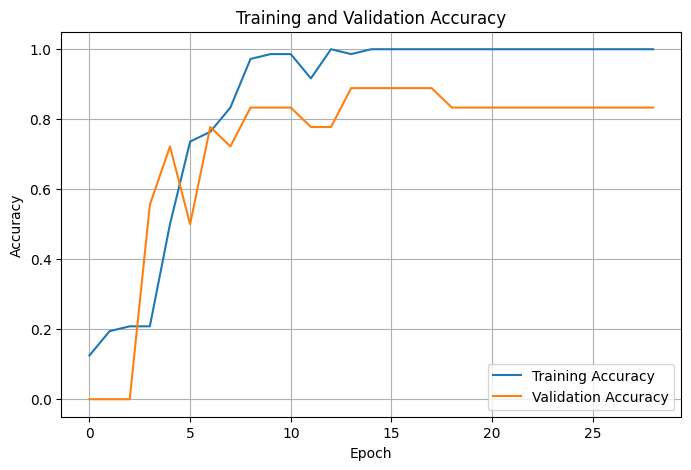

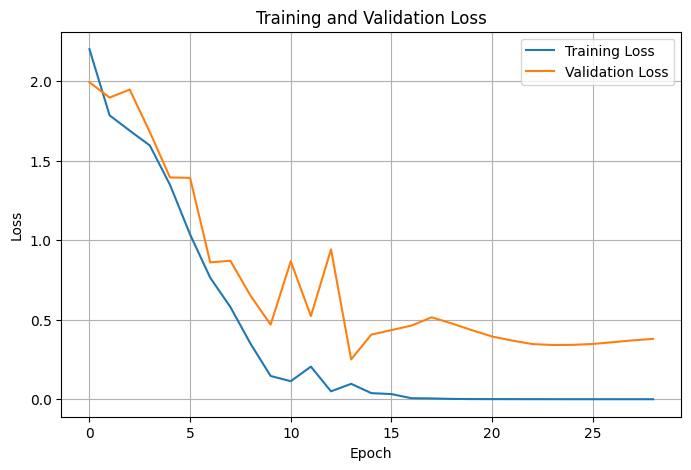

In [128]:
# Print classification report
print("Classification Report:")
print(classification_report(y_true, y_pred, target_names=class_names))

# Print confusion matrix
print("Confusion Matrix:")
print(confusion_matrix(y_true, y_pred))

# Plot training and validation accuracy
plt.figure(figsize=(8, 5))
plt.plot(history.history["accuracy"], label="Training Accuracy")
plt.plot(history.history["val_accuracy"], label="Validation Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Training and Validation Accuracy")
plt.legend()
plt.grid(True)
plt.show()

# Plot training and validation loss
plt.figure(figsize=(8, 5))
plt.plot(history.history["loss"], label="Training Loss")
plt.plot(history.history["val_loss"], label="Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training and Validation Loss")
plt.legend()
plt.grid(True)
plt.show()